# Credit Risk Modelling — Part 4.1: Setup & Load Preprocessed Data
---
**Objective:** Reload all raw data, run the full preprocessing pipeline from Part 3, and produce clean model-ready arrays — `X_train`, `X_test`, `y_train`, `y_test`, `sample_weights`.

Every subsequent notebook (4.2–4.10) loads the `.npy` files and `preprocessing_meta.pkl` saved at the end of this notebook.

## 1 — Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re, json, joblib, warnings
from pathlib import Path

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

BLUE, ORANGE, GREEN, RED, PURPLE = "#4472C4","#ED7D31","#70AD47","#C00000","#7030A0"
print("✓ Imports complete")

✓ Imports complete


## 2 — File Paths
Update these to point to your local CSV files.

In [6]:
TRAIN_X = "/Users/parveenkumarsharma/Documents/Ecom_project/Credit_risk_model/MP Credit Modelling Takehome Task (train + test) - X_train.csv"
TEST_X = "/Users/parveenkumarsharma/Documents/Ecom_project/Credit_risk_model/MP Credit Modelling Takehome Task (train + test) - X_test.csv"

TRAIN_Y = "/Users/parveenkumarsharma/Documents/Ecom_project/Credit_risk_model/MP Credit Modelling Takehome Task (train + test) - Y_train.csv"
TEST_Y = "/Users/parveenkumarsharma/Documents/Ecom_project/Credit_risk_model/MP Credit Modelling Takehome Task (train + test) - Y_test.csv"


for path in [TRAIN_X, TRAIN_Y, TEST_X, TEST_Y]:
    icon = "✓" if Path(path).exists() else "✗  FILE NOT FOUND"
    print(f"  {icon}  {path}")

  ✓  /Users/parveenkumarsharma/Documents/Ecom_project/Credit_risk_model/MP Credit Modelling Takehome Task (train + test) - X_train.csv
  ✓  /Users/parveenkumarsharma/Documents/Ecom_project/Credit_risk_model/MP Credit Modelling Takehome Task (train + test) - Y_train.csv
  ✓  /Users/parveenkumarsharma/Documents/Ecom_project/Credit_risk_model/MP Credit Modelling Takehome Task (train + test) - X_test.csv
  ✓  /Users/parveenkumarsharma/Documents/Ecom_project/Credit_risk_model/MP Credit Modelling Takehome Task (train + test) - Y_test.csv


## 3 — Load Raw Files & Merge

In [7]:
X_train_raw = pd.read_csv(TRAIN_X)
y_train_raw = pd.read_csv(TRAIN_Y)
X_test_raw  = pd.read_csv(TEST_X)
y_test_raw  = pd.read_csv(TEST_Y)

train = X_train_raw.merge(y_train_raw, on="account_id")
test  = X_test_raw.merge(y_test_raw,   on="account_id")

print(f"Train shape : {train.shape}")
print(f"Test  shape : {test.shape}")
print()
vc = train["label"].value_counts().sort_index()
print(f"Train label distribution:")
print(f"  No Default (0) : {vc[0]:>6,}  ({vc[0]/len(train)*100:.2f}%)")
print(f"  Default    (1) : {vc[1]:>6,}  ({vc[1]/len(train)*100:.2f}%)")
print(f"  Imbalance ratio: {vc[0]/vc[1]:.1f} : 1")

Train shape : (28397, 102)
Test  shape : (4000, 102)

Train label distribution:
  No Default (0) : 26,754  (94.21%)
  Default    (1) :  1,643  (5.79%)
  Imbalance ratio: 16.3 : 1


## 4 — Identify Feature Types

In [8]:
feature_cols = [c for c in X_train_raw.columns if c != "account_id"]
cat_cols     = [c for c in feature_cols if str(X_train_raw[c].dtype) in ("object", "str")]
num_cols     = [c for c in feature_cols if c not in cat_cols]

families = {}
for c in feature_cols:
    m = re.match(r"^([a-z_]+?)_\d+$", c)
    families.setdefault(m.group(1) if m else "other", []).append(c)

print(f"Total features    : {len(feature_cols)}")
print(f"Numeric features  : {len(num_cols)}")
print(f"Categorical feats : {len(cat_cols)}  ->  {cat_cols}")
print(f"Feature families  : {sorted(families.keys())}")

Total features    : 100
Numeric features  : 98
Categorical feats : 2  ->  ['financial_situation_4', 'financial_situation_5']
Feature families  : ['balance', 'credit_limit', 'demand_for_credit', 'financial_situation', 'recency', 'repayment_history', 'score', 'spend_behaviour', 'utilization']


## 5 — Preprocessing Pipeline
Exact same function from Part 3. **Medians and column lists are fit on train only.**

In [9]:
MISSING_THRESHOLD = 0.05
miss_pct  = X_train_raw[num_cols].isnull().mean()
flag_cols = miss_pct[miss_pct > MISSING_THRESHOLD].index.tolist()

print(f"Features getting missingness flags (>{int(MISSING_THRESHOLD*100)}% missing): {len(flag_cols)}")


def preprocess(df, num_cols, cat_cols, flag_cols,
               fit_medians=None, fit_modes=None, fit_feature_cols=None):
    """
    Full preprocessing pipeline:
      1. Binary missingness indicator flags  (NaN is informative in credit data)
      2. Median imputation for numeric NaNs  (fit on train only)
      3. One-hot encoding for categoricals   (NaN -> MISSING category)
      4. Column alignment                    (test must match train schema exactly)

    Pass fit_medians / fit_modes / fit_feature_cols to apply pre-fitted
    parameters to test data or new inference data without refitting.
    """
    df = df.copy()

    # 1. Missingness flags
    for col in flag_cols:
        if col in df.columns:
            df[f"{col}_is_missing"] = df[col].isnull().astype(np.int8)

    # 2. Median imputation (fit only if not provided)
    if fit_medians is None:
        fit_medians = df[num_cols].median()
    df[num_cols] = df[num_cols].fillna(fit_medians)

    # 3. Categorical encoding
    if cat_cols:
        if fit_modes is None:
            fit_modes = {c: "MISSING" for c in cat_cols}
        for c in cat_cols:
            df[c] = df[c].fillna(fit_modes[c])
        df = pd.get_dummies(df, columns=cat_cols, drop_first=False)

    # 4. Column alignment
    all_feat = [c for c in df.columns if c not in ["account_id", "label"]]
    if fit_feature_cols is not None:
        for c in fit_feature_cols:
            if c not in df.columns:
                df[c] = 0           # add missing dummy columns as zeros
        all_feat = fit_feature_cols  # enforce training column order
    return df, fit_medians, fit_modes, all_feat

Features getting missingness flags (>5% missing): 79


## 6 — Run Pipeline on Train & Test

In [10]:
# Fit on train
train_proc, medians, modes, feature_cols_final = preprocess(
    train, num_cols, cat_cols, flag_cols
)

# Apply pre-fitted params to test (no refitting)
test_proc, _, _, _ = preprocess(
    test, num_cols, cat_cols, flag_cols,
    fit_medians      = medians,
    fit_modes        = modes,
    fit_feature_cols = feature_cols_final
)

# Extract arrays
X_train = train_proc[feature_cols_final].values.astype(np.float32)
y_train = train_proc["label"].values.astype(np.int32)
X_test  = test_proc[feature_cols_final].values.astype(np.float32)
y_test  = test_proc["label"].values.astype(np.int32)

print(f"X_train : {X_train.shape}   NaN: {np.isnan(X_train).sum()}")
print(f"X_test  : {X_test.shape}    NaN: {np.isnan(X_test).sum()}")
print(f"y_train : {y_train.shape}   defaults: {y_train.sum():,} ({y_train.mean()*100:.2f}%)")
print(f"y_test  : {y_test.shape}    defaults: {y_test.sum():,} ({y_test.mean()*100:.2f}%)")
print()
n_flags  = len([c for c in feature_cols_final if c.endswith("_is_missing")])
n_dummies= len([c for c in feature_cols_final
                if any(c.startswith(cat + "_") for cat in cat_cols)])
n_orig   = len(feature_cols_final) - n_flags - n_dummies
print(f"Feature breakdown:")
print(f"  Original numeric  : {n_orig}")
print(f"  Missingness flags : {n_flags}")
print(f"  OHE dummy cols    : {n_dummies}")
print(f"  Total             : {len(feature_cols_final)}")

X_train : (28397, 198)   NaN: 0
X_test  : (4000, 198)    NaN: 0
y_train : (28397,)   defaults: 1,643 (5.79%)
y_test  : (4000,)    defaults: 234 (5.85%)

Feature breakdown:
  Original numeric  : 98
  Missingness flags : 79
  OHE dummy cols    : 21
  Total             : 198


## 7 — Sample Weights (Class Imbalance Correction)

In [11]:
pos = int(y_train.sum())
neg = int(len(y_train) - pos)
neg_pos_ratio = neg / pos

sample_weights = np.where(y_train == 1, neg_pos_ratio, 1.0)

print(f"Non-default (0) : {neg:>6,}")
print(f"Default     (1) : {pos:>6,}")
print(f"Ratio           : {neg_pos_ratio:.2f} : 1")
print()
print(f"Weight for class 0 : 1.00")
print(f"Weight for class 1 : {neg_pos_ratio:.2f}")
print()
w0 = sample_weights[y_train == 0].sum()
w1 = sample_weights[y_train == 1].sum()
print(f"Weighted mass class 0 : {w0:>10,.0f}")
print(f"Weighted mass class 1 : {w1:>10,.0f}")
print(f"Ratio after weighting : {w0/w1:.4f}  (should be 1.0  ✓)")

Non-default (0) : 26,754
Default     (1) :  1,643
Ratio           : 16.28 : 1

Weight for class 0 : 1.00
Weight for class 1 : 16.28

Weighted mass class 0 :     26,754
Weighted mass class 1 :     26,754
Ratio after weighting : 1.0000  (should be 1.0  ✓)


## 8 — Validation Checks

In [12]:
print("=" * 55)
print("  PREPROCESSING VALIDATION")
print("=" * 55)

checks = [
    ("No NaN in X_train",
     np.isnan(X_train).sum() == 0,
     f"{np.isnan(X_train).sum()} NaN"),

    ("No NaN in X_test",
     np.isnan(X_test).sum() == 0,
     f"{np.isnan(X_test).sum()} NaN"),

    ("Same column count: train vs test",
     X_train.shape[1] == X_test.shape[1],
     f"train={X_train.shape[1]}, test={X_test.shape[1]}"),

    ("y_train rows match X_train rows",
     len(y_train) == X_train.shape[0],
     f"{len(y_train)} == {X_train.shape[0]}"),

    ("y_test rows match X_test rows",
     len(y_test) == X_test.shape[0],
     f"{len(y_test)} == {X_test.shape[0]}"),

    ("Default rate preserved after processing",
     abs(y_train.mean() - train['label'].mean()) < 0.001,
     f"processed={y_train.mean():.4f}, raw={train['label'].mean():.4f}"),

    ("sample_weights length matches y_train",
     len(sample_weights) == len(y_train),
     f"length={len(sample_weights)}"),

    ("sample_weights are all positive",
     (sample_weights > 0).all(),
     f"min={sample_weights.min():.2f}"),
]

all_ok = True
for desc, passed, detail in checks:
    icon = "✓" if passed else "✗"
    print(f"  {icon}  {desc:<45}  [{detail}]")
    if not passed:
        all_ok = False

print()
if all_ok:
    print("  ✓✓  ALL CHECKS PASSED — ready for modelling")
else:
    print("  ✗   SOME CHECKS FAILED — review before continuing")

  PREPROCESSING VALIDATION
  ✓  No NaN in X_train                              [0 NaN]
  ✓  No NaN in X_test                               [0 NaN]
  ✓  Same column count: train vs test               [train=198, test=198]
  ✓  y_train rows match X_train rows                [28397 == 28397]
  ✓  y_test rows match X_test rows                  [4000 == 4000]
  ✓  Default rate preserved after processing        [processed=0.0579, raw=0.0579]
  ✓  sample_weights length matches y_train          [length=28397]
  ✓  sample_weights are all positive                [min=1.00]

  ✓✓  ALL CHECKS PASSED — ready for modelling


## 9 — Save Artefacts
All downstream notebooks (4.2–4.10) load these files.

In [14]:
# Preprocessing metadata
preprocessing_meta = {
    "num_cols"           : num_cols,
    "cat_cols"           : cat_cols,
    "flag_cols"          : flag_cols,
    "feature_cols_final" : feature_cols_final,
    "medians"            : medians.to_dict(),
    "modes"              : modes,
    "missing_threshold"  : MISSING_THRESHOLD,
    "neg_pos_ratio"      : float(neg_pos_ratio),
    "n_train"            : int(len(train)),
    "n_test"             : int(len(test)),
    "n_features"         : int(len(feature_cols_final)),
    "n_flag_cols"        : int(n_flags),
    "n_dummy_cols"       : int(n_dummies),
    "n_orig_num_cols"    : int(n_orig),
}
joblib.dump(preprocessing_meta, "preprocessing_meta.pkl")
print("✓  preprocessing_meta.pkl")

# Numpy arrays
np.save("X_train.npy",        X_train)
np.save("X_test.npy",         X_test)
np.save("y_train.npy",        y_train)
np.save("y_test.npy",         y_test)
np.save("sample_weights.npy", sample_weights)
print("✓  X_train.npy, X_test.npy, y_train.npy, y_test.npy, sample_weights.npy")

# Human-readable JSON summary (no medians — too verbose)
summary = {k: v for k, v in preprocessing_meta.items() if k != "medians"}
with open("part4_data_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
print("✓  part4_data_summary.json")
print()
print("All downstream notebooks load with:")
print("  meta   = joblib.load('preprocessing_meta.pkl')")
print("  X_train = np.load('X_train.npy')")
print("  y_train = np.load('y_train.npy')")

✓  preprocessing_meta.pkl
✓  X_train.npy, X_test.npy, y_train.npy, y_test.npy, sample_weights.npy
✓  part4_data_summary.json

All downstream notebooks load with:
  meta   = joblib.load('preprocessing_meta.pkl')
  X_train = np.load('X_train.npy')
  y_train = np.load('y_train.npy')


## 10 — Summary Visualisation

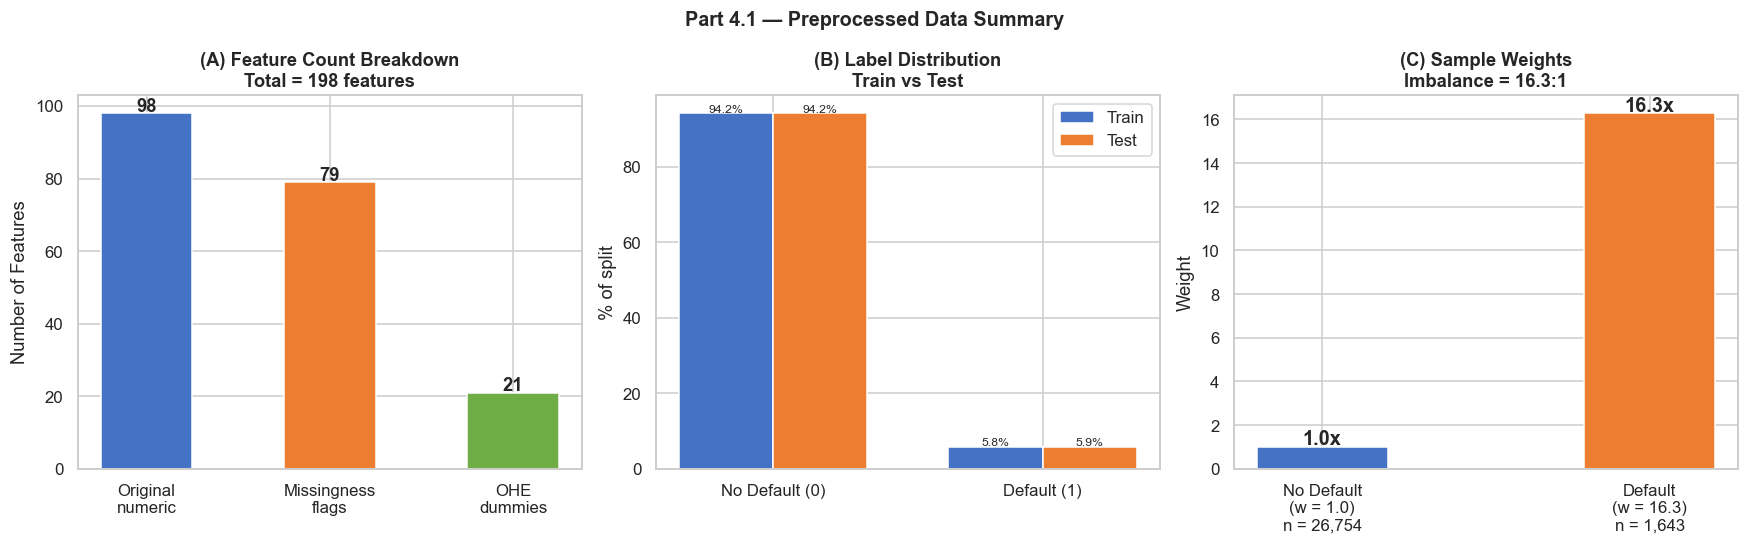

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Part 4.1 — Preprocessed Data Summary", fontsize=13, fontweight="bold")

# (A) Feature count breakdown
ax = axes[0]
feat_labels = ["Original\nnumeric", "Missingness\nflags", "OHE\ndummies"]
feat_vals   = [n_orig, n_flags, n_dummies]
feat_colors = [BLUE, ORANGE, GREEN]
bars = ax.bar(feat_labels, feat_vals, color=feat_colors, edgecolor="white", width=0.5)
ax.set_title(f"(A) Feature Count Breakdown\nTotal = {len(feature_cols_final)} features",
             fontweight="bold")
ax.set_ylabel("Number of Features")
for bar, val in zip(bars, feat_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha="center", fontsize=12, fontweight="bold")

# (B) Label distribution — train vs test
ax = axes[1]
x = np.arange(2); w = 0.35
b1 = ax.bar(x - w/2, [(1-y_train.mean())*100, y_train.mean()*100],
            w, label="Train", color=BLUE, edgecolor="white")
b2 = ax.bar(x + w/2, [(1-y_test.mean())*100, y_test.mean()*100],
            w, label="Test",  color=ORANGE, edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(["No Default (0)", "Default (1)"])
ax.set_ylabel("% of split")
ax.set_title("(B) Label Distribution\nTrain vs Test", fontweight="bold")
ax.legend()
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{bar.get_height():.1f}%", ha="center", fontsize=8)

# (C) Sample weight illustration
ax = axes[2]
sw_labels = [f"No Default\n(w = 1.0)\nn = {neg:,}",
             f"Default\n(w = {neg_pos_ratio:.1f})\nn = {pos:,}"]
sw_bars = ax.bar(sw_labels, [1.0, neg_pos_ratio],
                 color=[BLUE, ORANGE], edgecolor="white", width=0.4)
ax.set_title(f"(C) Sample Weights\nImbalance = {neg_pos_ratio:.1f}:1", fontweight="bold")
ax.set_ylabel("Weight")
for bar, val in zip(sw_bars, [1.0, neg_pos_ratio]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{val:.1f}x", ha="center", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()

---
## Summary

| | Value |
|---|---|
| `X_train` | 28,397 rows × 198 features |
| `X_test` | 4,000 rows × 198 features |
| NaN remaining | **0** |
| Original numeric features | 98 |
| Missingness flag features | 79 |
| OHE dummy features | 21 |
| Class imbalance | 16.3 : 1 |
| Default sample weight | **16.28×** |

### Files saved (load in notebooks 4.2–4.10)
```
preprocessing_meta.pkl   ← fitted params (medians, modes, column lists)
X_train.npy              ← processed feature matrix (train)
X_test.npy               ← processed feature matrix (test)
y_train.npy              ← label array (train)
y_test.npy               ← label array (test)
sample_weights.npy       ← per-row training weights
part4_data_summary.json  ← human-readable summary
```

---
**Next → Part 4.2: Define Evaluation Framework**  
Build the shared `evaluate_model()` function, KS statistic, Gini, and 5-fold CV strategy.